#### *Applied Mathematical Finance 2*

## <ins> *Seminar 4: Monte-Carlo integration and Copulae* </ins>

In [ ]:
import numpy as np
from scipy.optimize import minimize
from scipy.stats import norm
import matplotlib.pyplot as plt
from matplotlib import cm
import scipy

### 1. Monte-Carlo integration and Copulae

#### 1.1 Monte-Carlo integration setup

The problem of options pricing usually boils down to effective computation of an expectation of a given payoff function. That is, given a random vector of **dependent** variables $(X_1, \dots, X_n)$ with distribution function $H$, we may want to compute the expecation of $g(X_1, \dots, X_n)$ for some Borel function $g: \mathbb{R}^d \to \mathbb{R}$, which can be written as

$$\mathbb{E}g(X_1, \dots, X_n) = \int_{\mathbb{R}^n} g(X_1, \dots, X_n) dH(X_1, \dots, X_n).$$

* The problem here is that usually we do not know the joint distribution function $H(X_1, \dots, X_n)$ of variables $X_1, \dots, X_n$.

* However, what we do usually know are the marginal distributions $F_1(x), \dots, F_n(x)$ of $X_1, \dots, X_n$!

#### 1.2 Copulae in a nutshell

Consider a vector of random variables

$$X := (X_1, \dots, X_n), \qquad F_{i}(x) = \text{Pr}[X_i \leq x], \quad i = 1, \dots, n,$$

where $F_{i}(x)$ are the marginal cumulative distribution functions.


A **copula**  is the joint distribution function $$C: [0, 1]^n \to [0, 1]$$ of $(U_1, \dots, U_n)$, where $U_i \sim U[0, 1]$ are uniformly distributed random variables on $[0, 1]$. That is,     

$$C(u_1, \dots, u_n) = \text{Pr}[U_1 \leq u_1, \dots, U_n \leq u_n].$$

**Sklar's theorem**

Sklar's theorem provides a theoretical justification for the application of copulas. More precisely, this theorem states that every multivariate cumulative distribution function

$$H(x_1, \dots, x_n) = \text{Pr}[X_1 \leq x_1, \dots, X_n \leq x_n]$$

can be expressed in terms of its marginals $F_i(x) = \text{Pr}[X_i \leq x]$ and a copula $C$, that is

$$H(x_1, \dots, x_n) = C(F_1(x_1), \dots, F_n(x_n)).$$

Moreover, if the marginals $F_i(x)$ are continuous, then $H$ is unique!

Conversely, given a copula $C: [0, 1]^n \to [0, 1]$ and marginals $F_i(x)$, the function $C(F_1(x_1), \dots, F_n(x_n))$ defines a $n$-dimensional distribution function with marginals $F_i(x)$.

For the case of $n=2$, we can easily derive the density function of the copula.

Lets denote by $v_1 = F_1(x_1)$, $v_2 = F_2(x_2)$. Then

$$H(x_1, x_2) = C(v_1, v_2)$$
and
$$h(x_1, x_2) = \dfrac{\partial^2 H(x_1, x_2)}{\partial x_1 \partial x_2} = \dfrac{\partial^2 C(v_1, v_2)}{\partial v_1 \partial v_2} \cdot \dfrac{\partial F_1(x_1)}{\partial x_1} \cdot \dfrac{\partial F_2(x_2)}{\partial x_2} = c(v_1, v_2) \cdot f_1(x_1) \cdot f_2(x_2).$$

Therefore, the copula density function $c(v_1, v_2)$ is

$$
\begin{equation}
c(v_1, v_2) = \dfrac{h(F_1^{-1}(v_1), F_2^{-1}(v_2))}{f_1(F_1^{-1}(v_1)) f_2(F_2^{-1}(v_2))}.
\end{equation}
$$

$\textbf{Task 1}$:
- let $Y$ and $Z$ be two IID random variables each with CDF, $F(\cdot)$;
- let $X_1 := \min(Y, Z)$ and $X_2 := \max(Y, Z)$;
compute the copula, $C(u_1, u_2)$, of $(X_1, X_2)$.

#### 1.3 Gaussian copula

**Example (2d Gaussian copula)**

Assume we wish to construct a vector of two dependent uniform variates. We assume tha the Copula is given by the correlation matrix $\Sigma$ with corresponding square root $L$

$$
\Sigma =
\begin{pmatrix}
  1 & \rho\\
  \rho & 1
\end{pmatrix},
\quad
L =
\begin{pmatrix}
  1 & 0\\
  \rho & \sqrt{1 - \rho^2}
\end{pmatrix}.
$$  

Then
$$\tilde Z = (\tilde Z_1, \tilde Z_2) = (\Phi^{-1}(U_1), \quad \Phi^{-1}(U_2)),$$
where $U_1, U_2$ (respectively, $\tilde Z_1$, $\tilde Z_2$) are **independent** uniform (resp., gaussian) variates, and

$$Z = (Z_1, Z_2) = (\tilde Z_1, \quad \rho \tilde Z_1 + \sqrt{1 - \rho^2} \tilde Z_2)$$

where $Z_1, Z_2$ are correlated gaussian variables. Finally,

$$(V_1, V_2) = (\Phi(Z_1), \Phi(Z_2))$$

are dependent uniform variables, exactly what we wanted.

The copula density (following the formula (1)) can be given as


$$c(u_1, u_2) = \dfrac{1}{\sqrt{1 - \rho^2}} e^{-\dfrac{1}{2} \dfrac{\rho^2 (\Phi^{-1}(u_1))^2 - 2 \rho \Phi^{-1}(u_1) \Phi^{-1}(u_2) + \rho^2 (\Phi^{-1}(u_2))^2}{1 - \rho^2}}$$

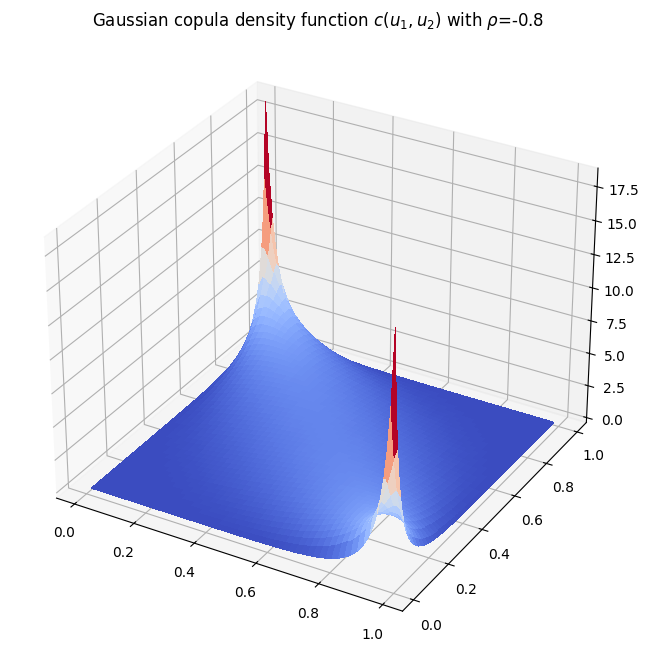

In [ ]:
rho = -0.8

n_grid = 100
eps = 0.01
u1 = np.linspace(eps, 1-eps, n_grid)
u2 = np.linspace(eps, 1-eps, n_grid)
U1, U2 = np.meshgrid(u1, u2)
c = 1 / np.sqrt(1 - rho**2) * np.exp(rho / (1 - rho**2) * norm.ppf(U1) * norm.ppf(U2) - rho**2 / 2 / (1 - rho**2) * (norm.ppf(U1)**2 + norm.ppf(U2)**2))

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": "3d"})
surf = ax.plot_surface(U1, U2, c, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)
ax.set_title("Gaussian copula density function $c(u_1, u_2)$ with $\\rho$={}".format(rho))
plt.show()

In [ ]:
random_seed = 42

In [ ]:
def sample_independent_uniform_variates(n_sample: int, size: int = 1, random_seed: int = 42):
    np.random.seed(random_seed)
    return np.random.rand(n_sample, size)

In [ ]:
sample_of_independent_uniform_variates = sample_independent_uniform_variates(n_sample=10000, size=2)

In [ ]:
def transform_uniform_to_gaussian(uniform_sample: np.ndarray):
    return norm.ppf(uniform_sample)
def transform_uniform_to_exponential(uniform_sample: np.ndarray):
    return scipy.stats.expon.ppf(uniform_sample)

In [ ]:
sample_of_independent_standard_gaussian_variates = transform_uniform_to_gaussian(uniform_sample=sample_of_independent_uniform_variates)

In [ ]:
def transform_gaussian_to_uniform(gaussian_sample: np.ndarray):
    return norm.cdf(gaussian_sample)

In [ ]:
sample_of_reversed_back_independent_uniform_variates = transform_gaussian_to_uniform(gaussian_sample=sample_of_independent_standard_gaussian_variates)

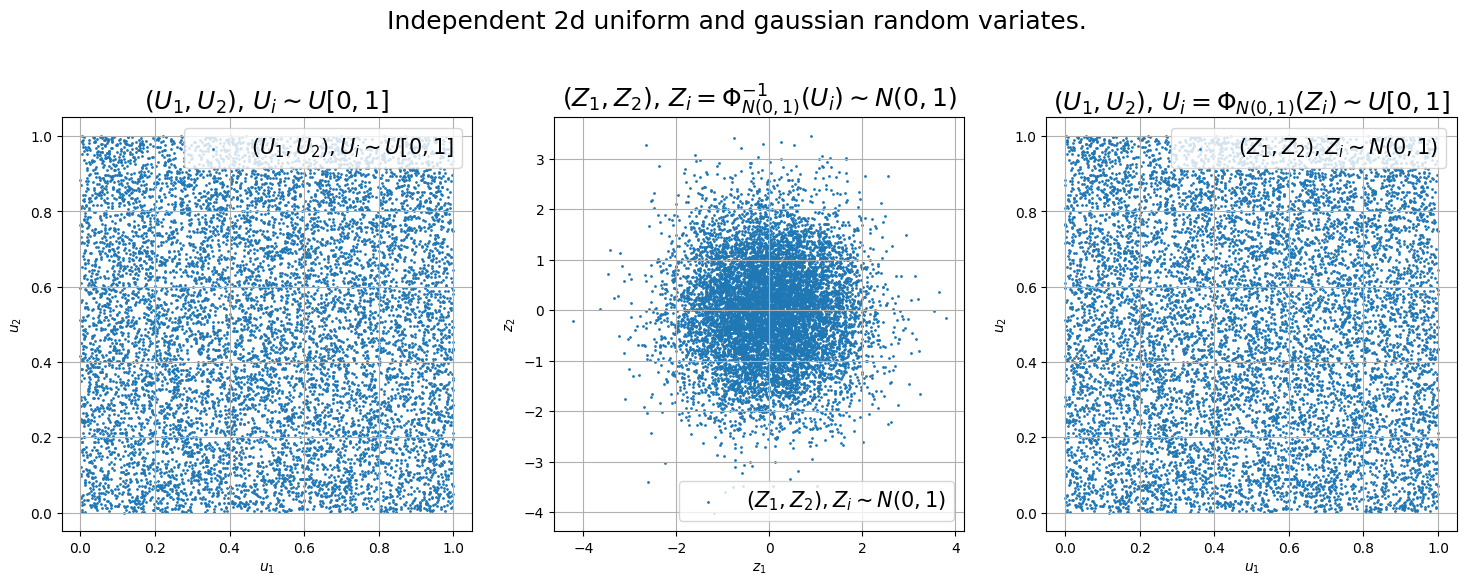

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
plt.rcParams.update({'font.size': 15, "axes.labelsize": 15})

ax[0].scatter(sample_of_independent_uniform_variates[:, 0], sample_of_independent_uniform_variates[:, 1], s=1, label="$(U_1, U_2), U_i \\sim U[0,1]$")
ax[1].scatter(sample_of_independent_standard_gaussian_variates[:, 0], sample_of_independent_standard_gaussian_variates[:, 1], s=1, label="$(Z_1, Z_2), Z_i \\sim N(0,1)$")
ax[2].scatter(sample_of_reversed_back_independent_uniform_variates[:, 0], sample_of_reversed_back_independent_uniform_variates[:, 1], s=1, label="$(Z_1, Z_2), Z_i \\sim N(0,1)$")

plt.suptitle("Independent 2d uniform and gaussian random variates.")
plt.subplots_adjust(top=0.8)

ax[0].set_title("$(U_1, U_2)$, $U_i \\sim U[0,1]$"), ax[0].set_xlabel('$u_1$'), ax[0].set_ylabel('$u_2$'), ax[0].legend()
ax[1].set_title("$(Z_1, Z_2)$, $Z_i = \\Phi^{-1}_{N(0, 1)}(U_i) \\sim N(0, 1)$"), ax[1].set_xlabel('$z_1$'), ax[1].set_ylabel('$z_2$'), ax[1].legend()
ax[2].set_title("$(U_1, U_2)$, $U_i = \\Phi_{N(0, 1)}(Z_i) \\sim U[0, 1]$"), ax[2].set_xlabel('$u_1$'), ax[2].set_ylabel('$u_2$'), ax[2].legend()
ax[0].grid(), ax[1].grid(), ax[2].grid()
plt.show()

In [ ]:
def cholesky_decomposition(x: np.ndarray):
    return np.linalg.cholesky(x)

In [ ]:
corr_matrix = np.array([[1, 0.8], [0.8, 1]])
square_root = cholesky_decomposition(x=corr_matrix)

In [ ]:
print("Correlation matrix C: \n {} \n".format(corr_matrix))
print("Square root L of C: \n {} \n".format(square_root))

Correlation matrix C: 
 [[1.  0.8]
 [0.8 1. ]] 

Square root L of C: 
 [[1.  0. ]
 [0.8 0.6]] 



In [ ]:
corr_coef = corr_matrix[0][1]

In [ ]:
size = corr_matrix.shape[0]
sample_of_independent_uniform_variates = sample_independent_uniform_variates(n_sample=10000, size=size)
sample_of_independent_standard_gaussian_variates = transform_uniform_to_gaussian(uniform_sample=sample_of_independent_uniform_variates)
square_root_matrix = cholesky_decomposition(x=corr_matrix)
sample_of_codependent_standard_gaussian_variates =  sample_of_independent_standard_gaussian_variates @ square_root_matrix.T
sample_of_codependent_uniform_variates = transform_gaussian_to_uniform(gaussian_sample=sample_of_codependent_standard_gaussian_variates)

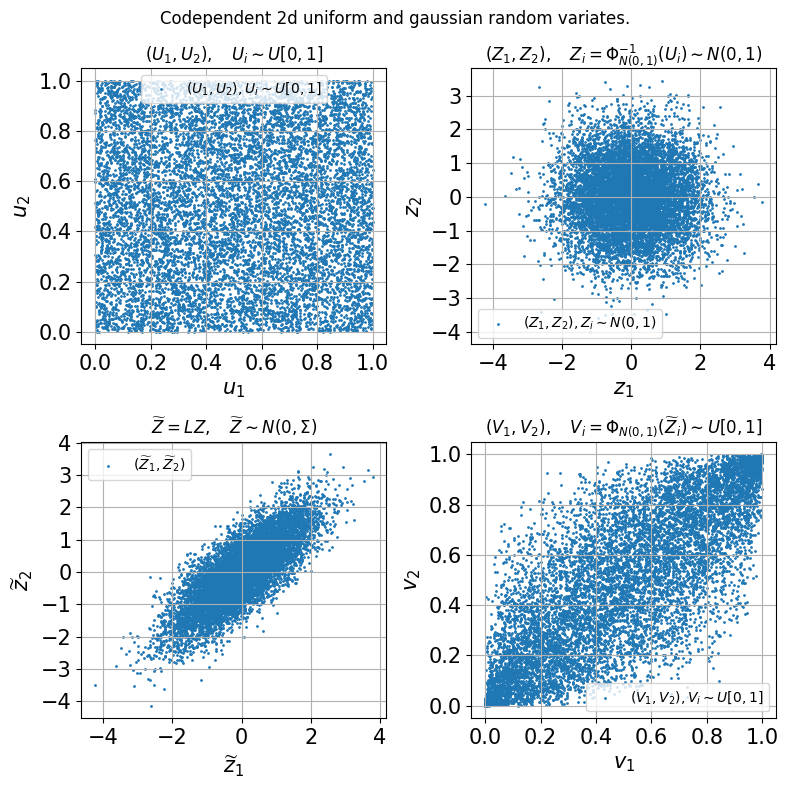

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(8, 8))
plt.rcParams.update({'font.size': 10, "axes.labelsize": 10})

ax[0][0].scatter(sample_of_independent_uniform_variates[:, 0], sample_of_independent_uniform_variates[:, 1], s=1, label="$(U_1, U_2), U_i \\sim U[0,1]$")
ax[0][1].scatter(sample_of_independent_standard_gaussian_variates[:, 0], sample_of_independent_standard_gaussian_variates[:, 1], s=1, label="$(Z_1, Z_2), Z_i \\sim N(0,1)$")
ax[1][0].scatter(sample_of_codependent_standard_gaussian_variates[:, 0], sample_of_codependent_standard_gaussian_variates[:, 1], s=1, label="$(\\widetilde Z_1, \\widetilde Z_2)$")
ax[1][1].scatter(sample_of_codependent_uniform_variates[:, 0], sample_of_codependent_uniform_variates[:, 1], s=1, label="$(V_1, V_2), V_i \\sim U[0,1]$")

plt.suptitle("Codependent 2d uniform and gaussian random variates.")
plt.subplots_adjust(top=0.9)

ax[0][0].set_title("$(U_1, U_2), \\quad U_i \\sim U[0,1]$"), ax[0][0].set_xlabel('$u_1$'), ax[0][0].set_ylabel('$u_2$'), ax[0][0].legend()
ax[0][1].set_title("$(Z_1, Z_2), \\quad Z_i = \\Phi^{-1}_{N(0, 1)}(U_i) \\sim N(0, 1)$"), ax[0][1].set_xlabel('$z_1$'), ax[0][1].set_ylabel('$z_2$'), ax[0][1].legend()
ax[1][0].set_title("$\\widetilde Z = LZ, \\quad \\widetilde Z \\sim N(0, \\Sigma)$"), ax[1][0].set_xlabel('$\\widetilde z_1$'), ax[1][0].set_ylabel('$\\widetilde z_2$'), ax[1][0].legend()
ax[1][1].set_title("$(V_1, V_2), \\quad V_i = \\Phi_{N(0, 1)}(\\widetilde Z_i) \\sim U[0, 1]$"), ax[1][1].set_xlabel('$v_1$'), ax[1][1].set_ylabel('$v_2$'), ax[1][1].legend()
ax[0][0].grid(), ax[0][1].grid(), ax[1][0].grid(), ax[1][1].grid()
fig.tight_layout()
plt.show()

In [ ]:
def correlations_of_copulaed_variates(rho: np.ndarray, marginal_dist_type: str = "uniform"):
    sample_of_independent_uniform_variates = sample_independent_uniform_variates(n_sample=10000, size=2)
    sample_of_independent_standard_gaussian_variates = transform_uniform_to_gaussian(uniform_sample=sample_of_independent_uniform_variates)
    correlations = list()
    for rho_ in rho:
        corr_matrix = np.array([[1, rho_], [rho_, 1]])
        square_root_matrix = cholesky_decomposition(x=corr_matrix)
        sample_of_codependent_standard_gaussian_variates =  sample_of_independent_standard_gaussian_variates @ square_root_matrix.T
        sample_of_codependent_uniform_variates = transform_gaussian_to_uniform(gaussian_sample=sample_of_codependent_standard_gaussian_variates)
        if (marginal_dist_type == "exp"):
          sample_of_codependent_variates = transform_uniform_to_exponential(sample_of_codependent_uniform_variates)
        else:
          sample_of_codependent_variates = sample_of_codependent_uniform_variates
        corr_ = np.corrcoef(sample_of_codependent_variates.T)[0][1]
        correlations.append(corr_)
    return correlations


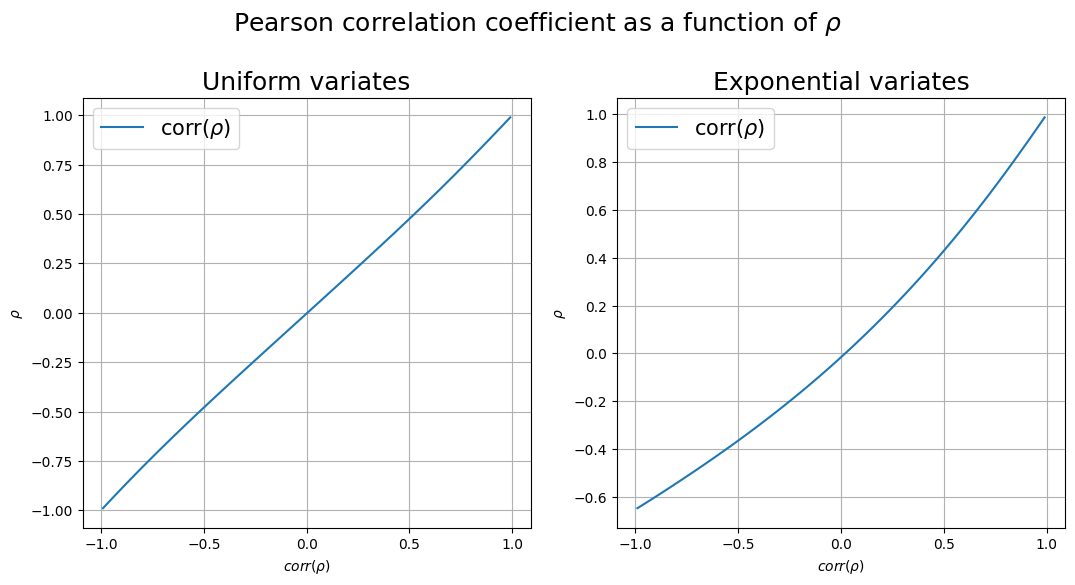

In [ ]:
rho = np.linspace(-0.99, 0.99, 100)
uniform_correlations = correlations_of_copulaed_variates(rho)
exp_correlations = correlations_of_copulaed_variates(rho,"exp")

fig, ax = plt.subplots(1, 2, figsize=(11, 6))
plt.rcParams.update({'font.size': 15, "axes.labelsize": 15})
plt.suptitle("Pearson correlation coefficient as a function of $\\rho$")
plt.subplots_adjust(top=0.8)

ax[0].plot(rho, uniform_correlations, label="corr($\\rho$)")
ax[1].plot(rho, exp_correlations, label="corr($\\rho$)")
ax[0].grid()
ax[1].grid()

ax[0].set_title("Uniform variates"), ax[0].set_xlabel("$corr(\\rho)$"), ax[0].set_ylabel("$\\rho$"), ax[0].legend()
ax[1].set_title("Exponential variates"), ax[1].set_xlabel("$corr(\\rho)$"), ax[1].set_ylabel("$\\rho$"), ax[1].legend()

fig.tight_layout()
plt.show()

#### 1.4 What is wrong with the case of exponential variables?

$\textbf{Theorem (The Fréchet-Hoeﬀding Bounds):}$ Consider a copula $C(\mathbf{u}) = C(u_1, \ldots , u_d)$. Then
$$
max \left\{1 - d + \sum_{i = 1}^{d}u_i, \; 0\right\} \;\leq\; C(\mathbf{u}) \;\leq\; \min \{u_1, \ldots , u_d\}.
$$

$\textbf{Sketch of Proof:}$

$\textit{First inequality:}$
$$
\begin{aligned}
C(\mathbf{u}) &= P\left(\bigcap_{1\leq i\leq d}\{U_i\leq u_i\}\right) \\
&= 1 - P\left(\bigcup_{1\leq i\leq d}\{U_i > u_i\}\right) \\
&\geq 1 - \sum_{i = 1}^{d}P(U_i > u_i) \quad \text{(by union bound)}\\
&= 1 - d + \sum_{i = 1}^{d}u_i.
\end{aligned}
$$
Since a probability is always non‑negative, we also have $C(\mathbf{u}) \ge 0$, so the lower bound is the maximum of the two.


$\textit{Second inequality:}$
$$
\bigcap_{1 \leq i \leq d} \{U_i \leq u_i\} \;\subseteq\; \{U_i \leq u_i\} \quad \text{for all } i.
$$
Taking probabilities gives $C(\mathbf{u}) \le u_i$ for every $i$, hence $C(\mathbf{u}) \le \min \{u_1, \ldots , u_d\}$. $\square$

The upper Fréchet-Hoeffding bound is tight for all $d$.

The lower Fréchet-Hoeffding bound is tight only when $d = 2$.

Fréchet and Hoeffding showed independently that copulas always lie between these bounds: corresponding to cases of extreme of dependency, i.e. comonotonicity and countermonotonicity.

The comonotonic copula is given by
$$
M(\mathbf{u}) := \min \{u_1, \ldots , u_d\}
$$
- the Fréchet-Hoeffding upper bound.

It corresponds to the case of extreme positive dependence.


$\textbf{Proposition:}$ Let $X_{1}, \ldots , X_{d}$ be random variables with continuous marginals and suppose $X_{i} = T_{i}(X_{1})$ for $i = 2, \ldots , d$ where $T_{2}, \ldots , T_{d}$ are strictly increasing transformations. Then $X_{1}, \ldots , X_{d}$ have the comonotonic copula.

The countermonotonic copula is the 2-dimensional copula that is the Fréchet-Hoeffding lower bound.

It satisfies
$$
W(u_{1},u_{2}) = \max \{u_{1} + u_{2} - 1,0\} \quad (1)
$$
and corresponds to the case of perfect negative dependence.

Can check that (1) is the joint distribution of $(U,1 - U)$ where $U \sim U(0,1)$.

$\textbf{Theorem}$

Let $X$ and $Y$ be random variables with joint cumulative distribution function $F_{X,Y}(x,y)$ and marginal cumulative distribution functions $F_X(x)$ and $F_Y(y)$. If $\mathbb{E}[X^2] < \infty$ and $\mathbb{E}[Y^2] < \infty$, then the covariance of $X$ and $Y$ can be expressed as
$$
\operatorname{Cov}(X,Y) = \iint_{\mathbb{R}^2} \left[ F_{X,Y}(x,y) - F_X(x)F_Y(y) \right] \, dx \, dy.
$$
$\textbf{Task 2:}$

compute linear correlation lower bound for two exponential random variables with intensity $\lambda_1$ and $\lambda_2.$


#### 1.5 Monte-Carlo integration

Recall that we are dealing with computation of the following integral

$$\mathbb{E}g(X_1, \dots, X_n) = \int_{\mathbb{R}^n} g(X_1, \dots, X_n) dH(X_1, \dots, X_n),$$

where $H(X_1, \dots, X_n)$ is a joint distribution function of $X_1, \dots, X_n$.

Applying Sklar's theorem, $H$ can be represented by some copula $C$, i.e.

$$H(x_1, \dots, x_n) = C(F_1(x_1), \dots, F_n(x_n)).$$

Therefore, the expectation from above can be written as

$$\mathbb{E}g(X_1, \dots, X_n) = \int_{[0, 1]^n} g(F^{-1}_1(u_1), \dots, F^{-1}_n(u_n)) dC(u_1, \dots, u_n).$$

Finally, the expectation can be estimated through the following Monte-Carlo algorithm

For each $k = 1, \dots, N$,
1. Draw a $k$-th sample $(U^k_1, \dots, U^k_n)$ from the copula $C$.

2. Set $(X^k_1, \dots, X^k_n) = (F^{-1}_1(U^k_1), \dots, F^{-1}_n(U^k_n))$.

Approximate $\mathbb{E}g(X_1, \dots, X_n)$ by its empirical analogue

$$\mathbb{E}g(X_1, \dots, X_n) \approx \dfrac{1}{N} \sum_{k=1}^{N} g(X^k_1, \dots, X^k_n).$$

The rate of convergence due to central limit theorem is $1/\sqrt{N}$.

**Example**

Let $S_1$ and $S_2$ be two gaussian random variables with correlation coefficient $\rho$. How we may compute their cross moment? We use the 2d Gaussian copula with covariance matrix equal to

$$
\begin{align*}
\Sigma =
\left(
\begin{matrix}
1 & \rho \\
\rho & 1 \\
\end{matrix}
\right)
\end{align*}.
$$



$$\mathbb{E}S_1 S_2 = \int_{\mathbb{R}^n} S_1 S_2 dH(S_1, S_2) = \int_{[0, 1]^2} F^{-1}_1(u_1) F^{-1}_2(u_2) dC(u_1, u_2).$$

For each $k = 1, \dots, N$,
1. Draw a $k$-th sample $(U^k_1, U^k_2)$ from the Gaussian copula $C$.

2. Set $(X^k_1, X^k_2) = (F^{-1}_1(U^k_1),F^{-1}_2(U^k_2))$.

Approximate $\mathbb{E} S_1 S_2$ by its empirical analogue

$$\mathbb{E} S_1 S_2 \approx \dfrac{1}{N} \sum_{k=1}^{N} X^k_1 X^k_2.$$


In [ ]:
def gaussian_copula(n_sample: int, corr_matrix: np.ndarray):
    size = corr_matrix.shape[0]
    sample_of_independent_uniform_variates = sample_independent_uniform_variates(n_sample=n_sample, size=size)
    sample_of_independent_standard_gaussian_variates = transform_uniform_to_gaussian(uniform_sample=sample_of_independent_uniform_variates)
    square_root_matrix = cholesky_decomposition(x=corr_matrix)
    sample_of_codependent_standard_gaussian_variates =  sample_of_independent_standard_gaussian_variates @ square_root_matrix.T
    sample_of_codependent_uniform_variates = transform_gaussian_to_uniform(gaussian_sample=sample_of_codependent_standard_gaussian_variates)
    return sample_of_codependent_uniform_variates


In [ ]:
sample_of_codependent_uniform_variates = gaussian_copula(n_sample=2**19, corr_matrix=corr_matrix)
sample_of_transformed_back_codependent_gaussian_variates =  transform_uniform_to_gaussian(uniform_sample=sample_of_codependent_uniform_variates)

In [ ]:
def first_moment(sample_of_gaussian_variates: np.ndarray):
    return np.mean(sample_of_gaussian_variates)

def second_moment(sample_of_gaussian_variates: np.ndarray):
    return np.std(sample_of_gaussian_variates)

def cross_moment(sample_of_gaussian_variates_1: np.ndarray, sample_of_gaussian_variates_2: np.ndarray):
    return np.mean(sample_of_gaussian_variates_1 * sample_of_gaussian_variates_2)

In [ ]:
def convergence_analysis(sample_of_codependent_gaussian_variates: np.ndarray, true_results: np.ndarray):
    maximum_number_of_iterations = sample_of_codependent_gaussian_variates.shape[0]
    results = np.zeros((int(np.log2(maximum_number_of_iterations)), 3))
    for i in range(results.shape[0]):
        results[i, 0] = np.abs(first_moment(sample_of_gaussian_variates=sample_of_codependent_gaussian_variates[:2**i, 1]) - true_results[0])
        results[i, 1] = np.abs(second_moment(sample_of_gaussian_variates=sample_of_codependent_gaussian_variates[:2**i, 1]) - true_results[1])
        results[i, 2] = np.abs(cross_moment(sample_of_gaussian_variates_1=sample_of_codependent_gaussian_variates[:2**i, 0],
                                         sample_of_gaussian_variates_2=sample_of_codependent_gaussian_variates[:2**i, 1]) - true_results[2])

    return results

In [ ]:
convergence_result = convergence_analysis(sample_of_codependent_gaussian_variates=sample_of_transformed_back_codependent_gaussian_variates,
                                          true_results=np.array([0, 1, corr_matrix[0][1]]))

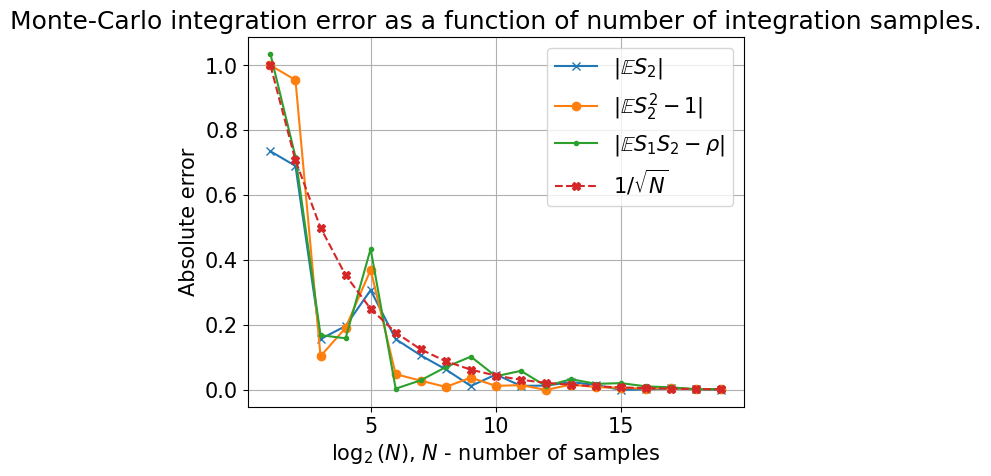

In [ ]:
log_2_iteratinos = np.linspace(1, 19, 19)
one_over_sqrt_N = 1 / np.sqrt([2**i for i in range(log_2_iteratinos.shape[0])])
one_over_sqrt_N
plt.plot(log_2_iteratinos, convergence_result[:, 0], label="$|\\mathbb{E}S_2|$", marker="x")
plt.plot(log_2_iteratinos, convergence_result[:, 1], label="$|\\mathbb{E} S_2^2 - 1|$", marker="o")
plt.plot(log_2_iteratinos, convergence_result[:, 2], label="$|\\mathbb{E} S_1S_2 - \\rho|$", marker=".")
plt.plot(np.linspace(1, 19, 19), one_over_sqrt_N, label="$1/\\sqrt{N}$", marker="X", linestyle="--")
plt.title('Monte-Carlo integration error as a function of number of integration samples.')
plt.xlabel("$\\log_2(N)$, $N$ - number of samples")
plt.ylabel("Absolute error")
plt.legend()
plt.grid()
plt.show()

### References

1. Jaeckel, Peter. “Monte Carlo methods in finance.” (2002).